<a href="https://colab.research.google.com/github/dimasjanotama/data-science-2026/blob/main/Pertemuan5_%5BDimas_Janotama%5D_%5B240401010264%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Dimas Prih P J<br>
NIM : 240401010264<br>
Kelas : IF403<br>

In [59]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

In [60]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('titanic')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(891, 15) survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


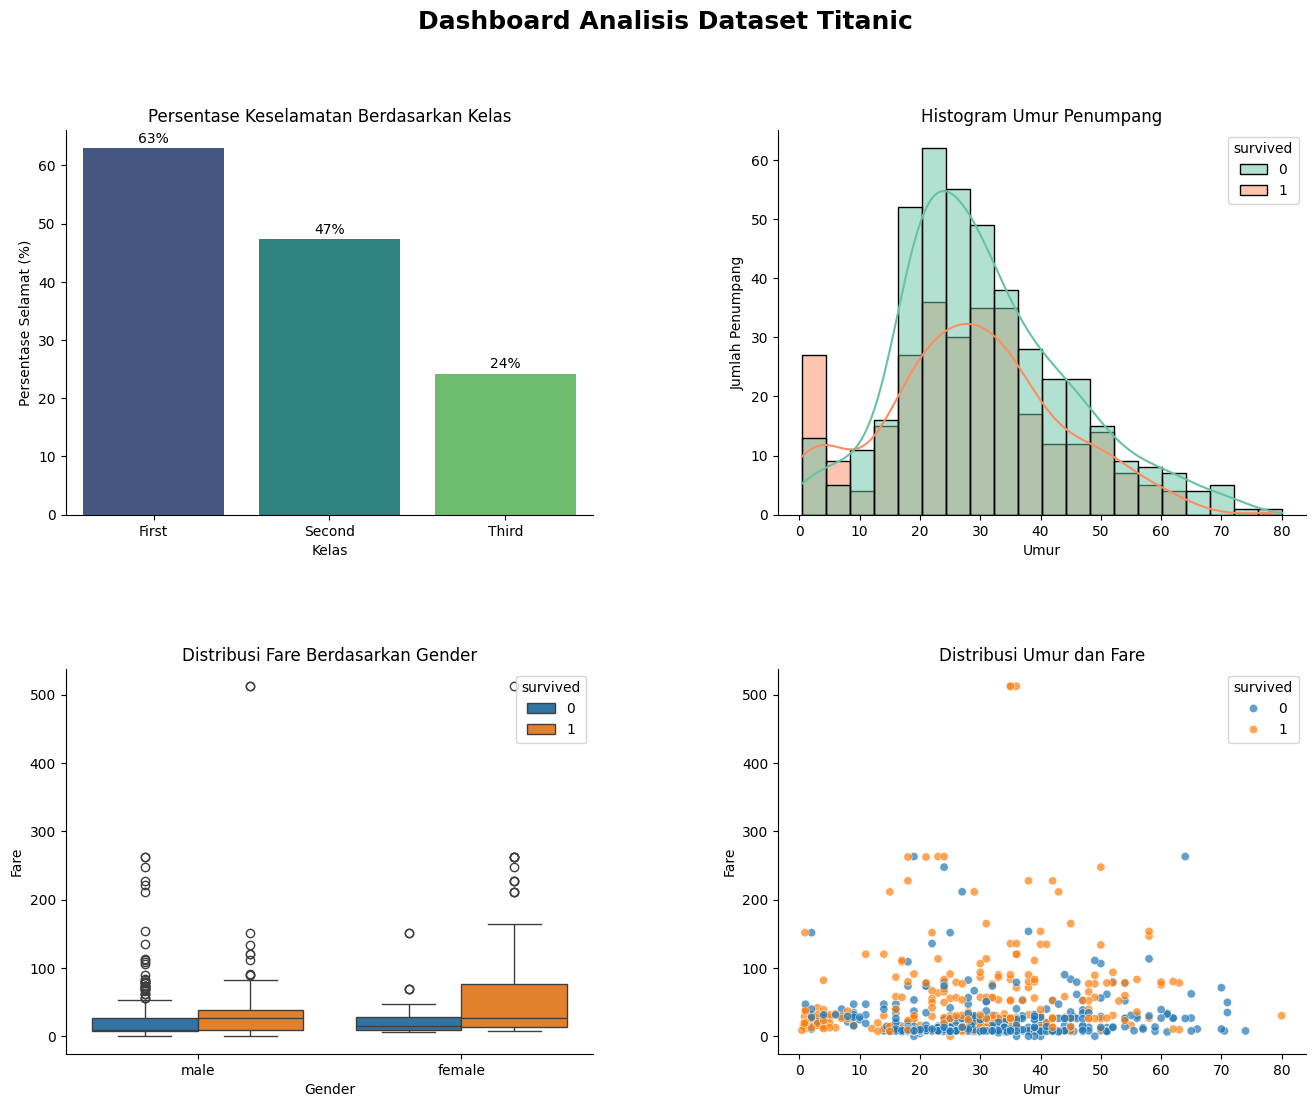

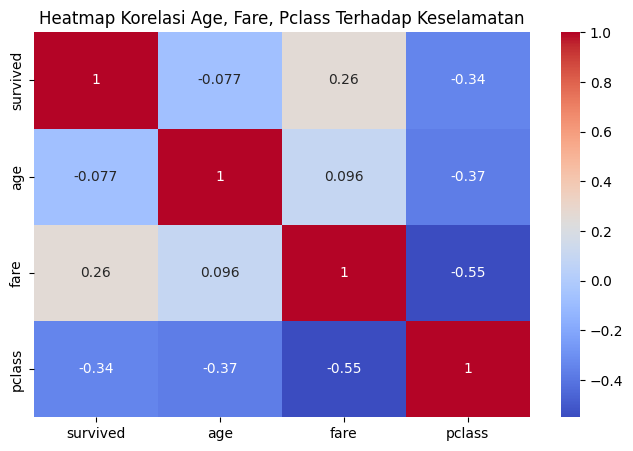

Dashboard berhasil disimpan!


In [61]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Titanic',
             fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
survival_by_class = df.groupby('class',observed=False)['survived'].mean() * 100
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, hue=survival_by_class.index,
    palette='viridis', legend=False, ax=ax1
)
ax1.set_title('Persentase Keselamatan Berdasarkan Kelas')
ax1.set_xlabel('Kelas')
ax1.set_ylabel('Persentase Selamat (%)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

for i, v in enumerate(survival_by_class.values):
    ax1.text(
        i,
        v + 1,
        f'{v:.0f}%',
        ha='center'
    )

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='age', hue='survived',
    kde=True, palette='Set2', ax=ax2
)

ax2.set_title('Histogram Umur Penumpang')
ax2.set_xlabel('Umur')
ax2.set_ylabel('Jumlah Penumpang')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='sex', y='fare',
    hue='survived', ax=ax3
)
ax3.set_title('Distribusi Fare Berdasarkan Gender')
ax3.set_xlabel('Gender')
ax3.set_ylabel('Fare')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='age', y='fare', hue='survived',
    sizes=(40, 200),alpha=0.7, ax=ax4
)
ax4.set_title('Distribusi Umur dan Fare')
ax4.set_xlabel('Umur')
ax4.set_ylabel('Fare')
ax4.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.heatmap( df[['survived','age','fare','pclass']].corr(),
            annot=True,  cmap='coolwarm'
            )
plt.title('Heatmap Korelasi Age, Fare, Pclass Terhadap Keselamatan')


# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_titanic.png', dpi=300, bbox_inches='tight')
plt.show()
print("Dashboard berhasil disimpan!")

#Interpretasi Data
##1. Barchart
- What : Penumpang di kelas satu memiliki tingkat keselamatan tertinggi (63%), diikuti oleh kelas dua (47%), dan kelas tiga memiliki tingkat keselamatan terendah (24%).
- So what : Menunjukkan adanya korelasi kuat antara status sosial-ekonomi yang direpresentasikan oleh kelas tiket dengan peluang selamat.
- Now what: Analisis lebih lanjut diperlukan untuk menguji apakah ada prioritas evakuasi berdasarkan kelas atau fasilitas keselamatan yang lebih baik antar kelas.

##2. Histogram
- What : Distribusi umur penumpang didominasi oleh kelompok dewasa muda (20–40 tahun).
- So what : Ada lonjakan tingkat survivability yang tinggi pada anak-anak (usia 0–10 tahun).
- Now what: Muncul dugaan kebijakan evakuasi anak-anak didahulukan, terlihat dari tingginya tingkat survived pada anak-anak.

##3. Boxplot
- What : Penumpang wanita memiliki harga tiket lebih bervariasi daripada pria.
- So what : Muncul asumsi Penumpang wanita banyak yang membayar lebih untuk tiket yang lebih mahal dibandingkan pria.
- Now what: Perlu analisa lanjutan untuk memastikan apakah wanita memang cenderung menempati kelas yang lebih tinggi atau harga tiketnya memang dibedakan berdasarkan gender

##4. Scatterplot
- What : Sebagian besar penumpang membayar tiket dengan harga rendah (di bawah 100) Penumpang yang selamat tersebar di berbagai tingkat harga tiket.
- So what : Dari data tersebut terlihat penumpang yang membayar tiket mahal cenderung memiliki peluang selamat lebih baik.
- Now what: Perlu analisa lanjutan untuk menyelidiki penumpang yang membayar tiket mahal namun tidak selamat.

##5. Heatmap
- What : Pclass memiliki korelasi terlemah terhadap survived (-0.34). Fare memiliki korelasi terkuat(0.26) terhadap survived.
- So what : variabel Fare adalah prediktor yang lebih berpengaruh terhadap keselamatan dibandingkan Age dan Pclass.
- Now what: Sejalan dengan hasil Scatterplot variabel Fare berpengaruh tinggi terhadap tingkat keselamatan, sehingga perlu dianalisa lebih lanjut terkait apa saja fasilitas yang tersedia dalam paket tiket yang mahal tersebut, yang dapat mulai diutamakan juga untuk paket dengan harga lebih rendah untuk meningkatkan tingkat survivability penumpang kapal jika terjadi kecelakaan.

#Yang Saya Pelajari
Pada pertemuan ini, saya mempelajari bagaimana memvisualisasikan data, mencari hubungan antara variabel seperti kelas tiket, usia, dan harga tiket menggunakan library Python untuk menangkap pola di dalam suatu data dalam hal ini tingkat survivability. Saya memeplajari cara menginterpretasikan distribusi data melalui Barchart, histogram, boxplot, scatterplot, dan heatmap.